<a href="https://colab.research.google.com/github/KenzaMeziati/MLPro_Exercices/blob/main/MethodoIA_M1_MLPro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DataAnalysis_Exercice1: Life Expectancy

**1. Determine which variables in the dataset are discrete and continuous.**
* Discrete variables: Year, Country
* Continuous variables: Spending_USD, Life_Expectancy


**2. Analyze the "Country" variable.**
* Univariate analysis of a discrete variable: calculating frequencies using value_counts: Japan & USA 51, Germany 50, Canada 44, Great Britain 43 and France 35

**3. Analyze the "Spending_USD" variable.**

**- Clearly explain the meaning of the mean from this analysis (Be very precise, it's important):** The calculated average shows a value of 2789.338905 located between a min of 123.993000 and a max of 11859.179000 and close to the 50th percentile 2295.578000, this value suggests a non-homogeneous distribution of values ​​among the studied population with an average pulled towards the lowest values.

**- Create the two graphs needed for this analysis :** sns.boxplot(df['Spending_USD]'), sns.displot(df['Spending_USD'])

**4. Do the same for the "Life_Expectancy" variable.**
- The value of the mean seems correct
- sns.boxplot(df['Life_Expectancy']), sns.displot(df['Life_Expectancy'])

**5. Observe the evolution of life expectancy over time.**
- plt.figure(figsize=(12, 6))
df.groupby("Year")["Life_Expectancy"].mean().plot(kind='bar', color='peachpuff')
plt.show()

**6. Oops... How can this graph be improved?**
- plt.figure(figsize=(12, 6))

**7. Observe the evolution of healthcare spending in Germany and Great Britain over time.**
- df1 = df[(df['Country'] == 'Germany') | (df['Country'] == 'Great Britain')]
plt.figure(figsize=(12, 6))
df1.groupby("Year")["Spending_USD"].mean().plot(kind='bar', color='peachpuff')
plt.show()

**8. Observe the histogram, boxplot, and "Life_Expectancy" statistics specific to each country.**
- for country in df['Country'].unique():
    - Summary statistics:
    print(f"--- {country} ---")
    print(df[df['Country'] == country]['Life_Expectancy'].describe())
    
    - Distribution plot:
    sns.displot(df[df['Country'] == country]['Life_Expectancy'], color="peachpuff")
    plt.title(f"Life Expectancy Distribution - {country}")
    plt.show()
    
    - Boxplot:
    sns.boxplot(df[df['Country'] == country]['Life_Expectancy'], color="peachpuff")
    plt.title(f"Life Expectancy Boxplot - {country}")
    plt.show()

**9. Observe the relationship between life expectancy and healthcare spending in the United States from 2000 to 2020.**
- df2 = df[(df['Country']== 'USA') &  (df['Year'] >= 2000) & (df['Year'] <= 2020)]
- sns.scatterplot(data=df2, x='Life_Expectancy', y='Spending_USD')

**10. There is an outlier in all of this. What is it? Why?**
- df2[(df2['Year']==2020)]
	Year	Country	Spending_USD	Life_Expectancy
  2020	USA	     11859.179	   77.0
--> This was probably linked to the covid-19 pandemic.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = sns.load_dataset("healthexp")
df.head()

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9


In [ ]:
df.shape # numbers of rows and columns

(274, 4)

In [ ]:
print(df.dtypes) # the dataset's variables and their respective type
#print(df.dtypes.value_counts) #for each type, calculates the number of variables in the dataset

Year                 int64
Country             object
Spending_USD       float64
Life_Expectancy    float64
dtype: object


Country
USA              51
Japan            51
Germany          50
Canada           44
Great Britain    43
France           35
Name: count, dtype: int64


<Axes: xlabel='Country'>

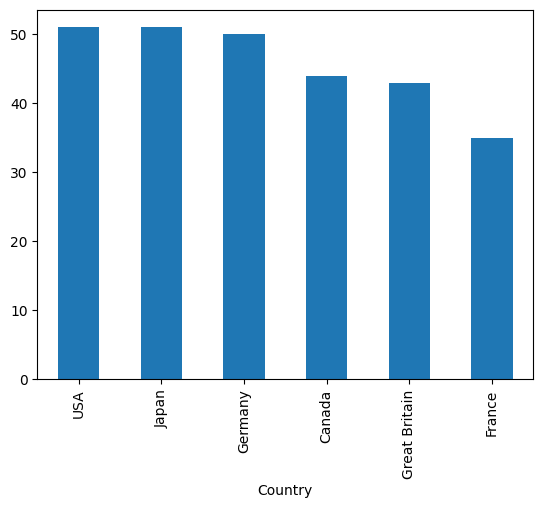

In [ ]:
print(df['Country'].value_counts()) # Univariate analysis of a discrete variable: calculating frequencies using value_counts
df['Country'].value_counts().plot(kind="bar") # bar plot for the univariate analysis of Country

count      274.000000
mean      2789.338905
std       2194.939785
min        123.993000
25%       1038.357000
50%       2295.578000
75%       4055.610000
max      11859.179000
Name: Spending_USD, dtype: float64


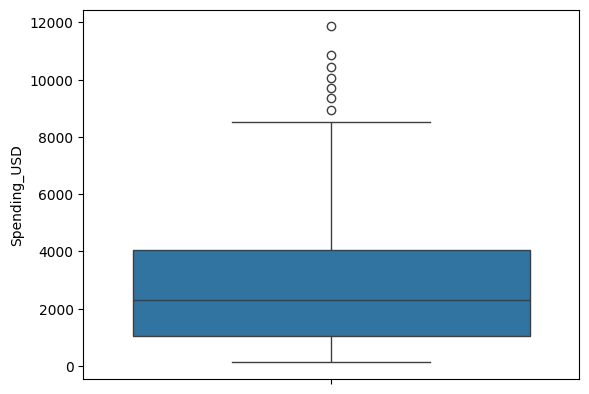

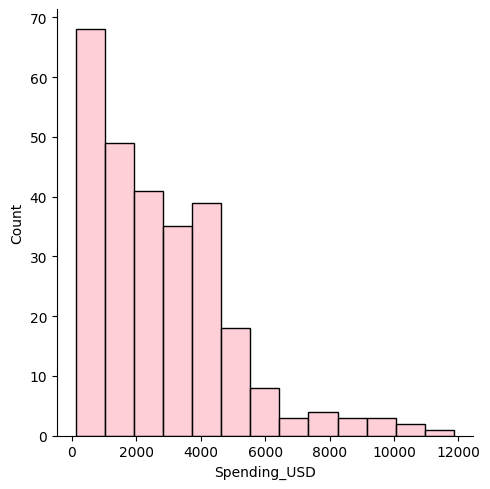

In [ ]:
print(df['Spending_USD'].describe()) # Univariate analysis of a continuous variable : calculating metrics using describe()
sns.boxplot(df['Spending_USD'])
sns.displot(df['Spending_USD'], color='pink')

count    274.000000
mean      77.909489
std        3.276263
min       70.600000
25%       75.525000
50%       78.100000
75%       80.575000
max       84.700000
Name: Life_Expectancy, dtype: float64


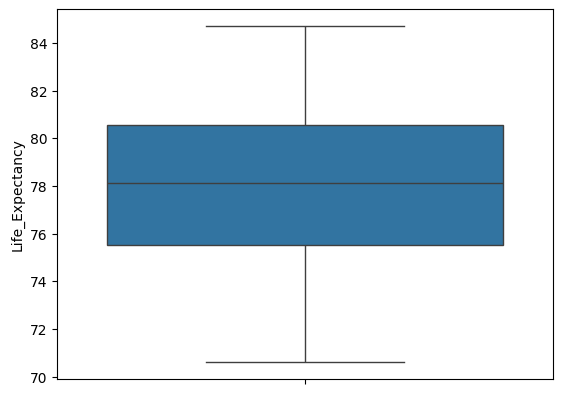

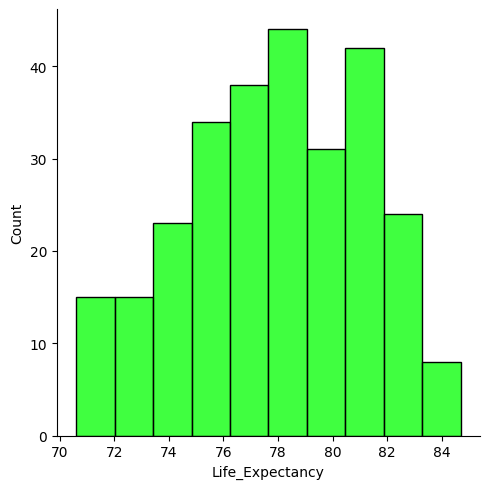

In [ ]:
print(df['Life_Expectancy'].describe())
sns.boxplot(df['Life_Expectancy'])
sns.displot(df['Life_Expectancy'], color='lime') #https://matplotlib.org/stable/gallery/color/named_colors.html

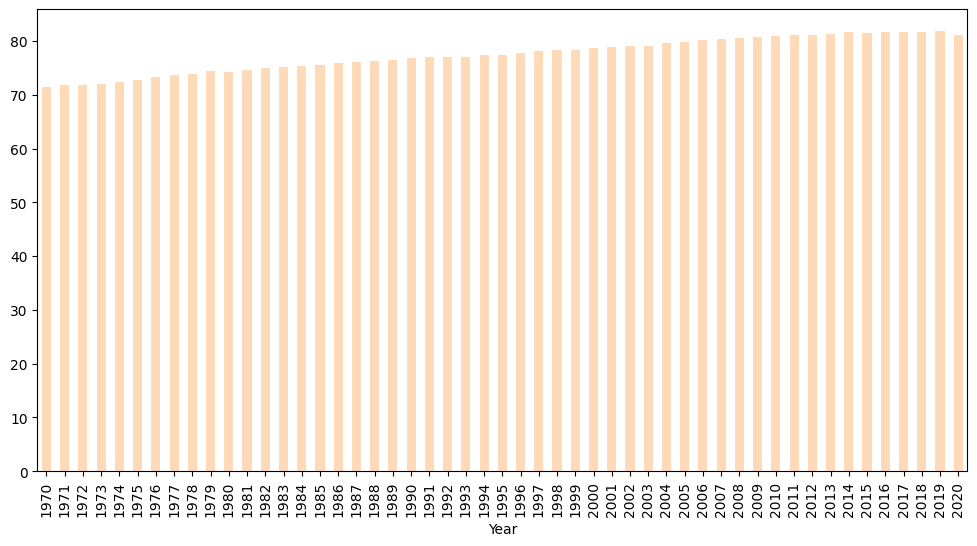

In [ ]:
plt.figure(figsize=(12, 6))
df.groupby("Year")["Life_Expectancy"].mean().plot(kind='bar', color='peachpuff')
plt.show()

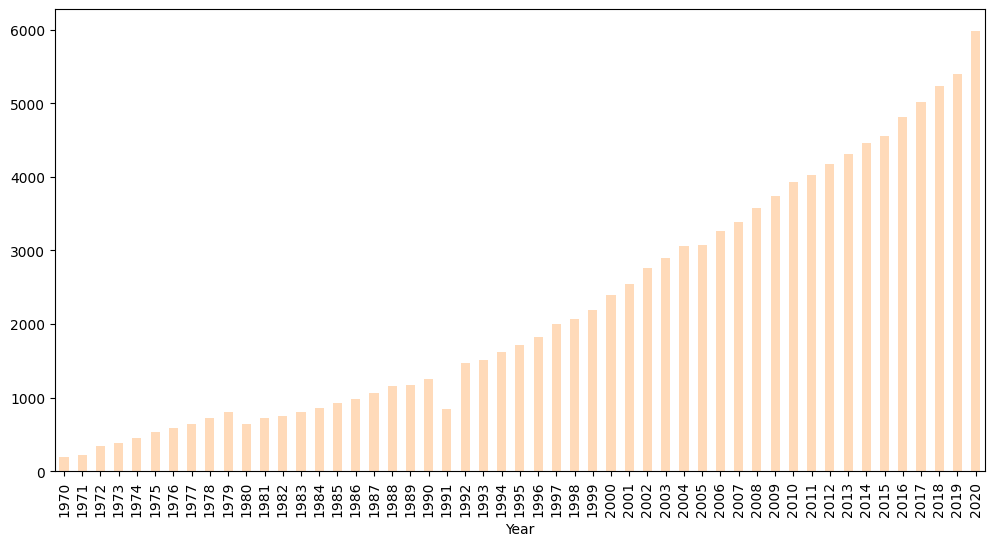

In [ ]:
df1 = df[(df['Country'] == 'Germany') | (df['Country'] == 'Great Britain')]
plt.figure(figsize=(12, 6))
df1.groupby("Year")["Spending_USD"].mean().plot(kind='bar', color='peachpuff')
plt.show()

--- Germany ---
count    50.000000
mean     76.726000
std       3.473915
min      70.600000
25%      73.575000
50%      77.100000
75%      80.175000
max      81.300000
Name: Life_Expectancy, dtype: float64


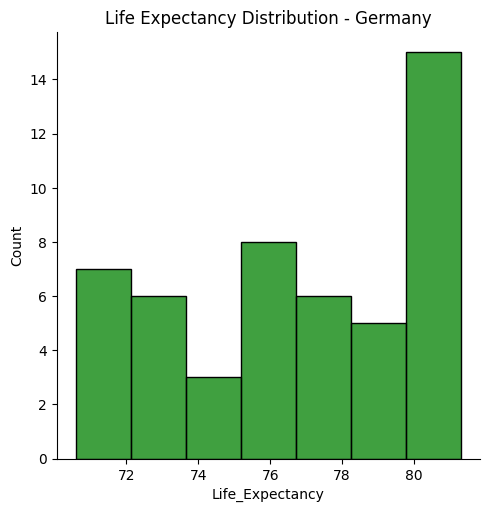

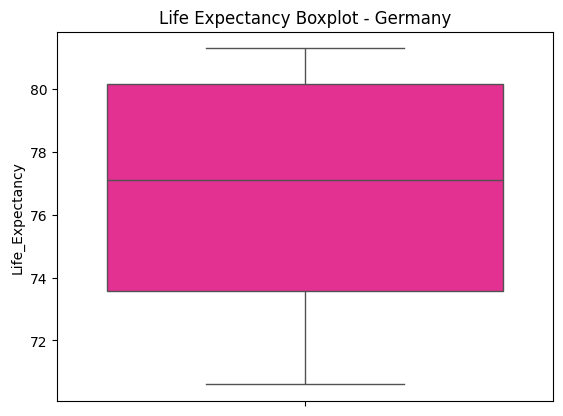

--- France ---
count    35.000000
mean     79.565714
std       2.862120
min      72.200000
25%      78.050000
50%      79.400000
75%      82.200000
max      82.900000
Name: Life_Expectancy, dtype: float64


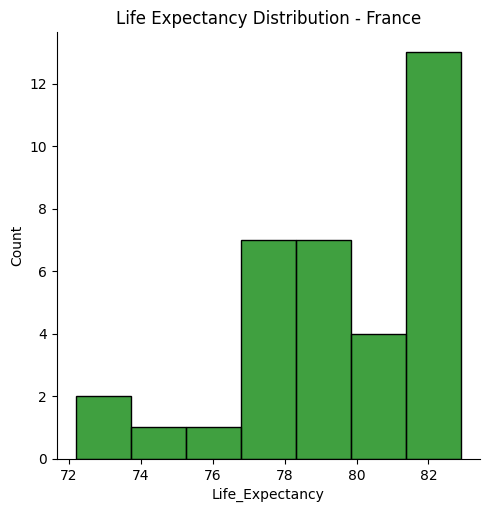

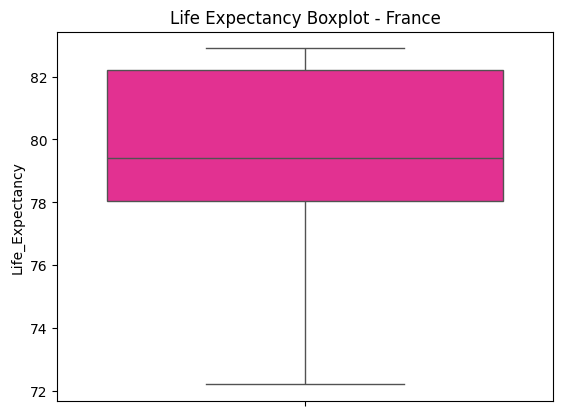

--- Great Britain ---
count    43.000000
mean     77.620930
std       2.827548
min      71.900000
25%      75.350000
50%      77.500000
75%      80.400000
max      81.400000
Name: Life_Expectancy, dtype: float64


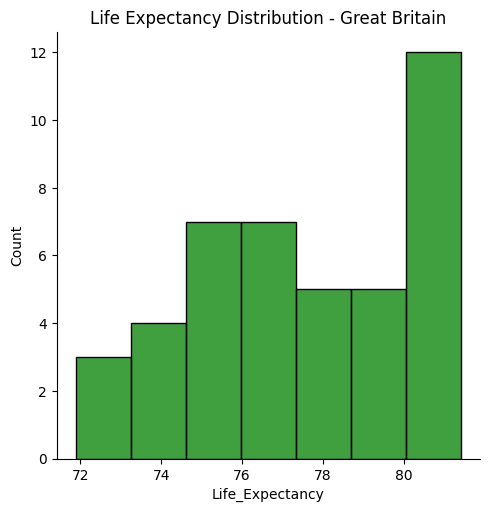

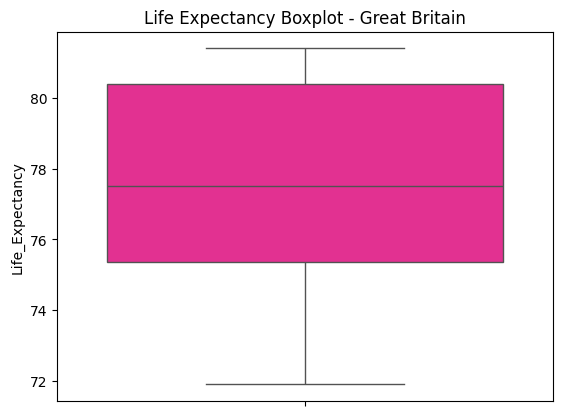

--- Japan ---
count    51.000000
mean     79.554902
std       3.547242
min      72.000000
25%      76.950000
50%      79.800000
75%      82.650000
max      84.700000
Name: Life_Expectancy, dtype: float64


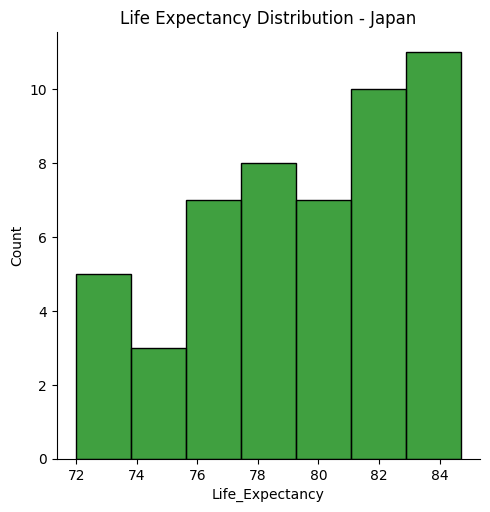

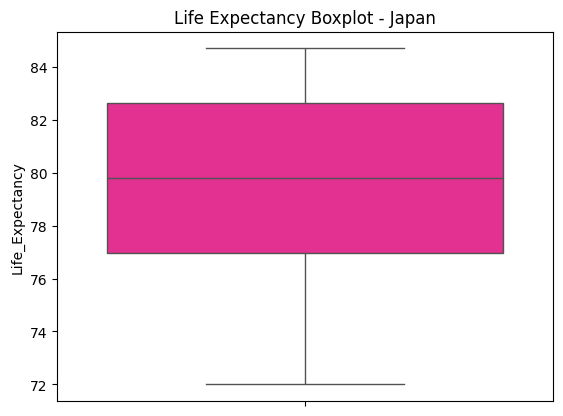

--- USA ---
count    51.000000
mean     75.843137
std       2.336258
min      70.900000
25%      74.550000
50%      75.700000
75%      77.950000
max      78.900000
Name: Life_Expectancy, dtype: float64


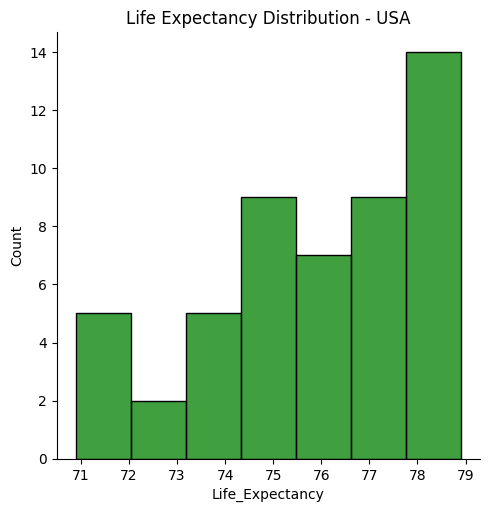

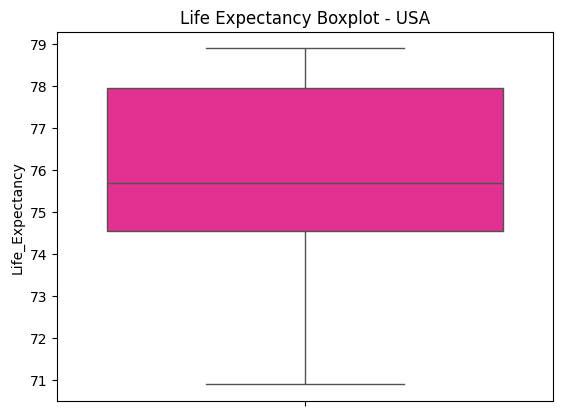

--- Canada ---
count    44.000000
mean     78.706818
std       2.502222
min      72.800000
25%      76.775000
50%      78.700000
75%      80.975000
max      82.200000
Name: Life_Expectancy, dtype: float64


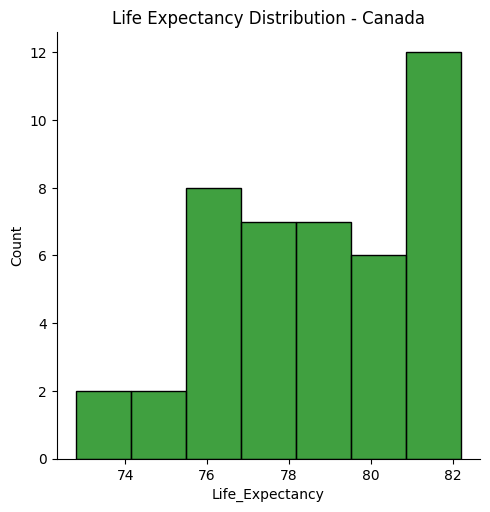

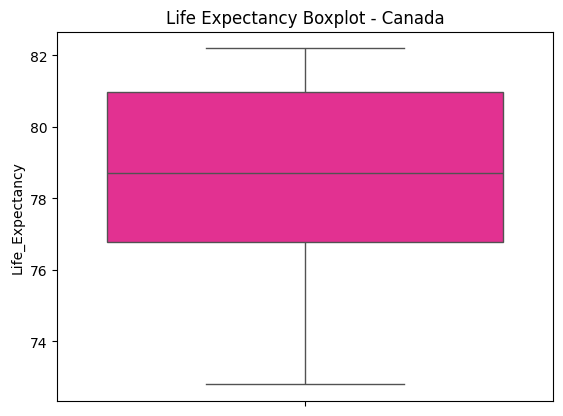

In [ ]:
for country in df['Country'].unique():
    # Summary statistics
    print(f"--- {country} ---")
    print(df[df['Country'] == country]['Life_Expectancy'].describe())

    # Distribution plot
    sns.displot(df[df['Country'] == country]['Life_Expectancy'], color="green")
    plt.title(f"Life Expectancy Distribution - {country}")
    plt.show()

    # Boxplot
    sns.boxplot(df[df['Country'] == country]['Life_Expectancy'], color="deeppink")
    plt.title(f"Life Expectancy Boxplot - {country}")
    plt.show()

In [ ]:
df2 = df[(df['Country']== 'USA') &  (df['Year'] >= 2000) & (df['Year'] <= 2020)]
df2.shape

(21, 4)

<Axes: xlabel='Life_Expectancy', ylabel='Spending_USD'>

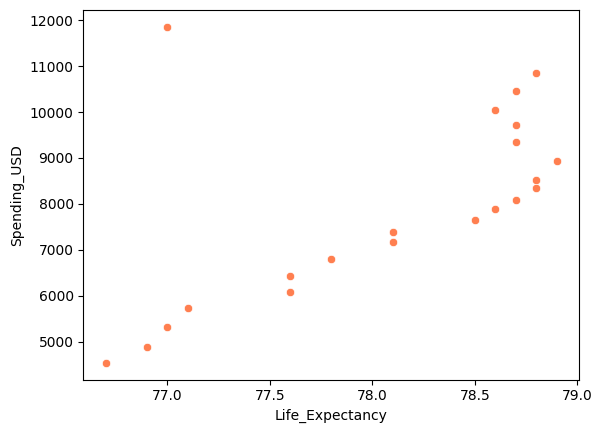

In [ ]:
sns.scatterplot(data=df2, x='Life_Expectancy', y='Spending_USD', color = 'coral')

In [ ]:
df2

,Year,Country,Spending_USD,Life_Expectancy
153,2000,USA,4536.561,76.7
159,2001,USA,4888.518,76.9
165,2002,USA,5316.522,77.0
171,2003,USA,5726.538,77.1
177,2004,USA,6069.530,77.6
183,2005,USA,6430.757,77.6
189,2006,USA,6808.054,77.8
195,2007,USA,7166.513,78.1
201,2008,USA,7385.026,78.1
207,2009,USA,7645.002,78.5


In [ ]:
df2[(df2['Year']==2020)]

,Year,Country,Spending_USD,Life_Expectancy
273,2020,USA,11859.179,77.0


# DataAnalysis_Exercice2: Miles per Gallon

**1. Quelles sont les variables discrètes et continues de ce dataset ?**
- Variables discrètes : cylinders, model_year, origin, name
- Variables Continues : mpg, displacement, weight, horsepower, acceleration

**2. Analysez la variable mpg.**

- **Quelle est la moyenne ? Que représente-t'elle vraiment ? (soyez clair et précis !)** : la moyenne est à peu près de 23.45 mpg et elle représente la distance en miles parcourue en moyenne par gallon consommé de carburant pour tous les modèles de voitures cités dans la liste étudiée.

- **Tracez les 2 graphiques utiles pour cette variable** histplot et boxplot de seaborn.

**3. Analysez la variable "cylinders"** les moteurs à 4, 8 et 6 cylindres sont les plus courants dans ce jeu de données. Les 5 et 3 cylindres sont les moins fréquents.

**4. Analysez la variable "origin"** dfa["origin"].value_counts().sort_index()

**5. Observez l'évolution de la consommation des voitures (mpg) par rapport au nombre de chevaux (horsepower)**

**- Que semble-t-on voir ?** il semblerait que le mpg est une fonction décroissante du horsepower : plus le moteur est puissant plus faible est la distance parcourue par gallon consommé et vice versa; les moteurs puissants consommeraient plus de carburant

**- Rajoutez-y la variable de l'année du modèle. Que voit-on ?** les modèles récents sont moins puissants mais ont un meilleur ratio mpg

**6. Observez l'évolution du poids moyen des voitures américaines de l'année 70 jusqu'à l'année 82.**

**- Que semble-t-on voir ?** Il semblerait que le poids des véhicules diminue en moyenne avec le temps pour ce pays

**- Voit-on également cela pour les autres pays ?** non, pour le japon, l'évolution est plutôt stagnante et pour l'europe on peut remarquer des hauts et des bas sans une particulière tendance claire

**7. Analysez la relation entre le nombre de cylindres et l'année du modèle.**

**- Se dégage-t'il quelque chose de cette analyse ?** Cela confirmerait ce qui a été observé en répondant à la Q.5 les voitures les plus récentes ont un nombre inférieur de cylindres et donc sont moins puissantes

**8. Analysez la relation entre le nombre de cylindres et l'origine.**

**- Se dégage-t'il quelque chose de cette analyse ?** Le Japon et l'Europe n'ont pas construit de V8 entre les années 70 et 82 et ont construit peu de V6, l'Europe est l'unique à avoir essayé le V5, le V4 reste le dominant pour ces 2 origines. Les us ont une grande expérience en V8 avec une construction prononcée de V6 et V4 également (à garder en tête que la table de données ne contient pas un nombre équitable de lignes relatives à chaque origine, l'image reflétée est donc strictement liée au jeu de données étudié)

**9. Quelle est l'accélération moyenne des voitures des différents pays ?** entre les années 70 à 82, l'accélération moyenne (unité à confirmer si m/s²) des voitures des différents pays est environ :
- japon : 16.2 , europe : 16.8 et us : 15

**10. Quelle est-elle pour les modèles de l'année 80 ?** Pour les modèles de l'année 80, l'accélération en moyenne était de :
- japon : 16.01 , europe : 18.36 et us : 16.80

**11. Au final Il semblerait qu'une tendance se dégage à travers le temps...**

**- faites la liste de tous les phénomènes qui semblent se produire (diminution ? augmentation ?) pour les différentes variables et groupes**
- mpg : augmentation, puissance (cylindres) : diminution, poids : diminution, accélération : augmentation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
dfa =  sns.load_dataset("mpg")
print(dfa.head())
dfa.info()

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2 

In [ ]:
dfa.dropna(inplace = True)
dfa.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    object 
 8   name          392 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 30.6+ KB


In [ ]:
print(dfa.dtypes.value_counts())

float64    4
int64      3
object     2
Name: count, dtype: int64


In [ ]:
import matplotlib
print("pandas version:", pd.__version__)
print("matplotlib version:", matplotlib.__version__)
print("seaborn version:", sns.__version__)

pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


In [ ]:
dfa.nunique()

,0
mpg,127
cylinders,5
displacement,81
horsepower,93
weight,346
acceleration,95
model_year,13
origin,3
name,301


In [ ]:
dfa["mpg"].describe()

,mpg
count,392.000000
mean,23.445918
std,7.805007
min,9.000000
25%,17.000000
50%,22.750000
75%,29.000000
max,46.600000


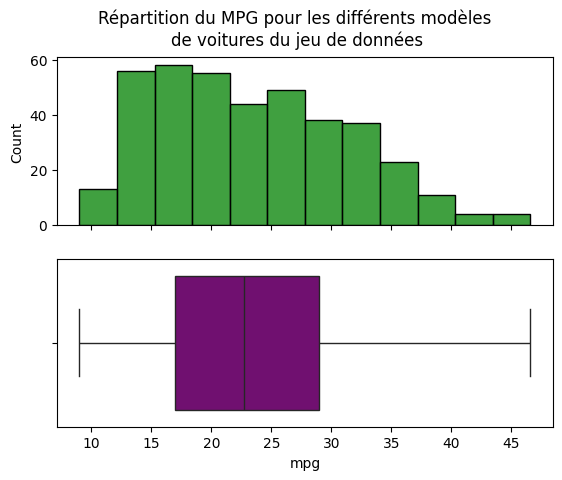

In [ ]:
fig, ax = plt.subplots(2,1,sharex=True)
plt.suptitle("Répartition du MPG pour les différents modèles \nde voitures du jeu de données")
sns.histplot(data=dfa, x="mpg", ax=ax[0], color='green')
sns.boxplot(data=dfa, x="mpg", ax=ax[1], color='purple')
plt.show()

In [ ]:
dfa["cylinders"].value_counts().sort_index()

,count
cylinders,
3,4
4,199
5,3
6,83
8,103


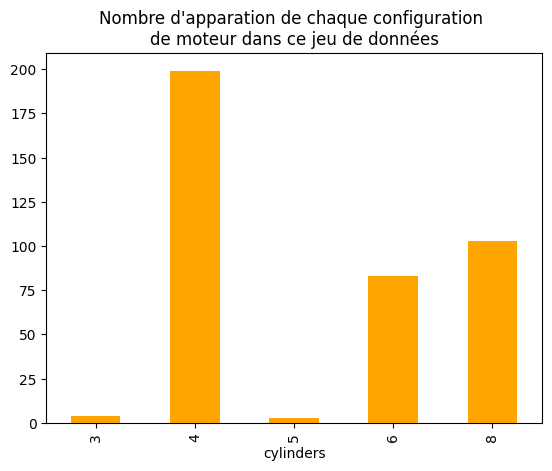

In [ ]:
dfa["cylinders"].value_counts().sort_index().plot(kind='bar', color='orange')
plt.title("Nombre d'apparation de chaque configuration \nde moteur dans ce jeu de données")
plt.show()
#sns.countplot(data=dfa, x="cylinders")

origin
europe     68
japan      79
usa       245
Name: count, dtype: int64


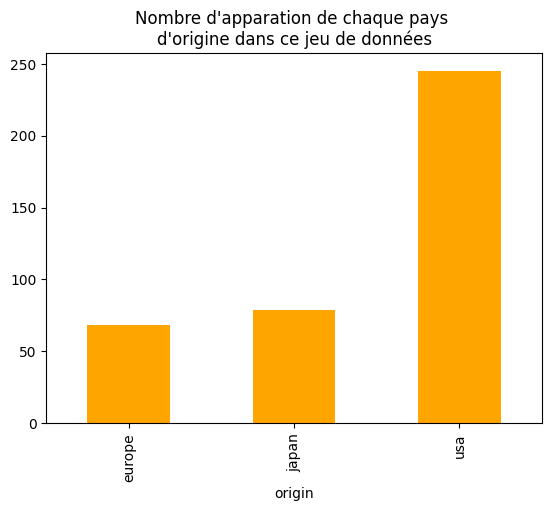

In [ ]:
print(dfa["origin"].value_counts().sort_index())
dfa["origin"].value_counts().sort_index().plot(kind='bar', color='orange')
plt.title("Nombre d'apparation de chaque pays \nd'origine dans ce jeu de données")
plt.show()
#sns.countplot(data=dfa, x="origin")

<Axes: xlabel='horsepower', ylabel='mpg'>

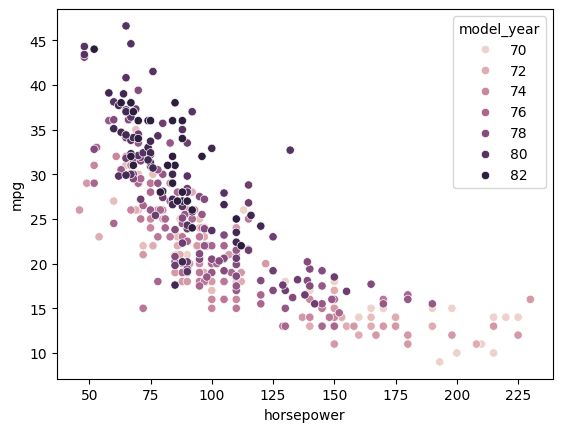

In [ ]:
sns.scatterplot(data=dfa, x="horsepower", y="mpg", hue="model_year")

In [ ]:
table =  dfa.query("origin == 'usa' & model_year >= 70")
table.groupby('model_year')['weight'].describe()

NameError: name 'dfa' is not defined

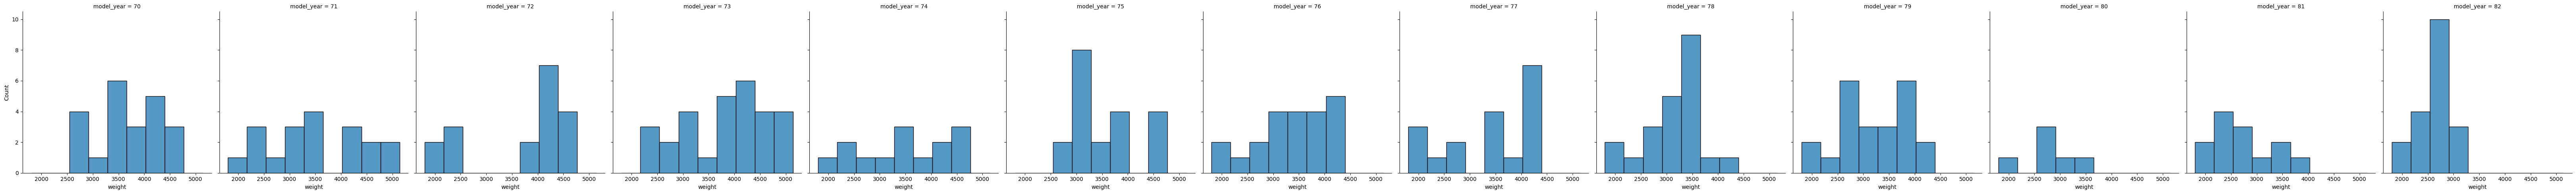

In [ ]:
sns.displot(data=table, x='weight', col='model_year')

<Axes: xlabel='model_year', ylabel='weight'>

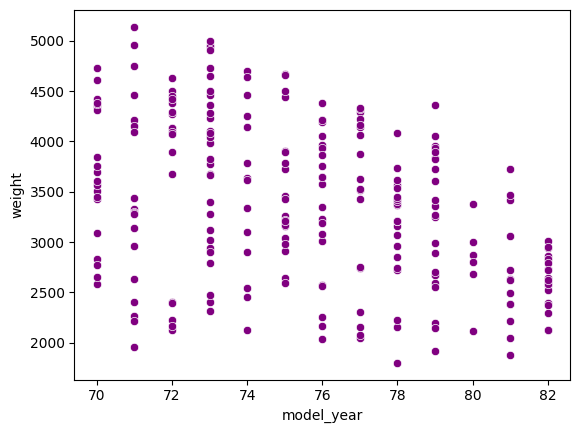

In [ ]:
sns.scatterplot(data=table, x="model_year", y="weight", color='purple')
#mean_weights = table.groupby('model_year')['weight'].mean().reset_index()
#sns.scatterplot(data=mean_weights, x='model_year', y='weight')

<Axes: xlabel='model_year', ylabel='weight'>

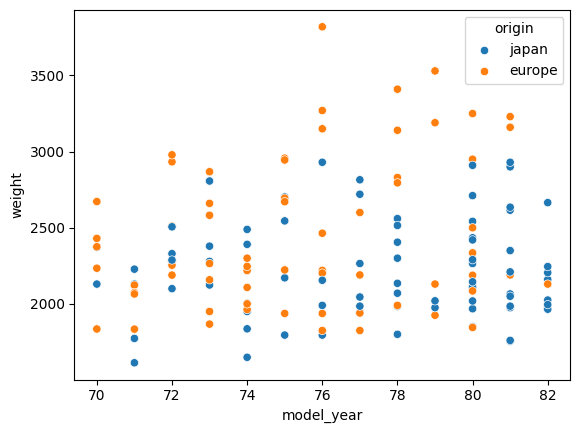

In [ ]:
sns.scatterplot(data= dfa.query("origin != 'usa' & model_year >= 70"), x='model_year', y='weight', hue='origin')
#table1 = dfa.query("origin == 'japan' & model_year >= 70")
#table1.groupby('model_year')['weight'].describe()

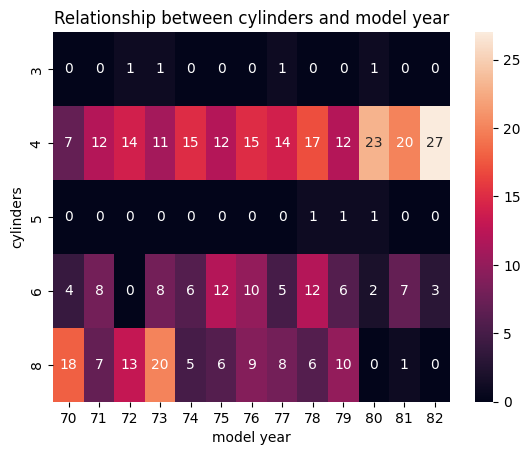

In [ ]:
sns.heatmap(pd.crosstab(dfa['cylinders'], dfa['model_year']), annot = True, fmt ='d')
plt.title('Relationship between cylinders and model year')
plt.xlabel('model year')
plt.ylabel('cylinders')
plt.show()

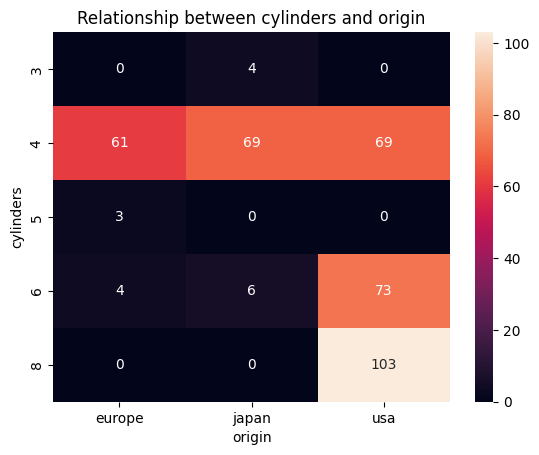

In [ ]:
sns.heatmap(pd.crosstab(dfa['cylinders'], dfa['origin']), annot = True, fmt = 'd')
plt.title("Relationship between cylinders and origin")
plt.xlabel("origin")
plt.ylabel("cylinders")
plt.show()

<Axes: xlabel='model_year', ylabel='weight'>

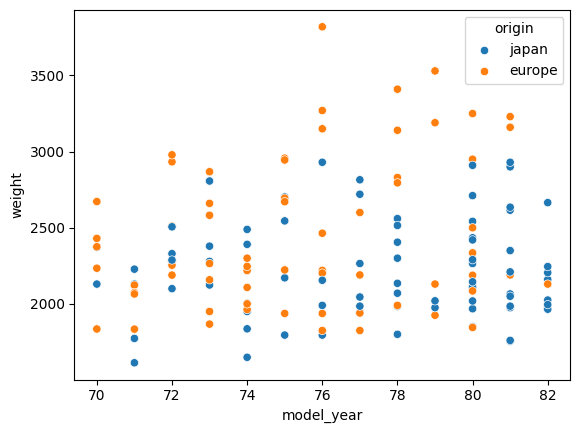

In [ ]:
dfa.groupby('origin')['acceleration'].describe()

,count,mean,std,min,25%,50%,75%,max
origin,,,,,,,,
europe,68.0,16.794118,3.087813,12.2,14.5,15.6,19.125,24.8
japan,79.0,16.172152,1.954937,11.4,14.6,16.4,17.550,21.0
usa,245.0,14.990204,2.736020,8.0,13.0,15.0,16.700,22.2


In [ ]:
table2 = dfa[(dfa["model_year"] == 80)]
table2.groupby('origin')['acceleration'].describe()

,count,mean,std,min,25%,50%,75%,max
origin,,,,,,,,
europe,9.0,18.366667,3.444924,14.7,15.30,17.3,21.7,23.7
japan,13.0,16.015385,2.402029,11.4,15.00,16.4,17.9,19.2
usa,7.0,16.800000,2.235322,14.3,14.95,16.5,18.4,20.1


<Axes: xlabel='model_year', ylabel='acceleration'>

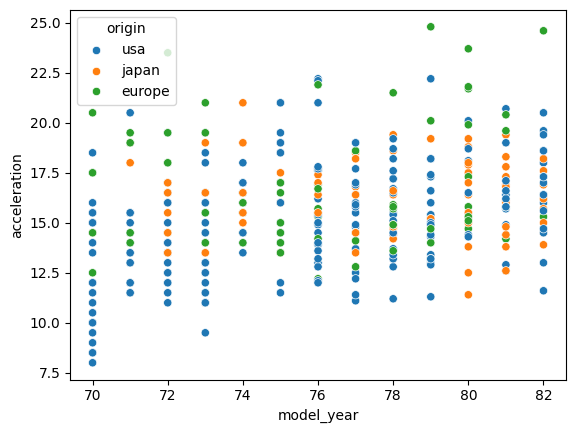

In [ ]:
sns.scatterplot(data = dfa, x = "model_year", y = "acceleration", hue = "origin")

# DataAnalysis_Exercice3: Anscombe

**1. Analysez la relation entre x et y.** il semblerait que y évolue en fonction de x dans ce jeu de données et considérant l'ensemble des catégories 'dataset'
en séparant les groupes, l'évolution s'avère hétérogène

**2. Y a-t-il une meilleure manière d’analyser les choses ? Adaptez votre graphique** tracer l'évolution de la moyenne de y en fonction de x (on pourrait également séparer les groupes)

**3. Analysez maintenant les statistiques de chaque "paquet". Que constatez-vous ?** Pour les deux variable x et y, on constate: même nombre de ligne, moyenne et écart-type pour tous les paquets. Valeurs très rapprochées voir identiques pour le reste des mesures statistiques pour tous les paquets, sauf pour la variable x du 4ème paquet où 10 lignes ont une valeur de 8 et une ligne avec une valeur de 19

**3. Quels sont les 2 enseignements que vous pouvez tirer de cette analyse ?** 1- Sans contexte on ne peut pas expliquer ou approffondir l'analyse. 2- Une valeur identique de moyenne, écart-type, etc, ne veut pas forcément dire une même répartition de valeurs dans différents paquets de données.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
print("pandas version:", pd.__version__)
print("matplotlib version:", matplotlib.__version__)
print("seaborn version:", sns.__version__)


pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


In [ ]:
dfb = sns.load_dataset("anscombe")
dfb.head()

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


In [ ]:
dfb.info()
dfb.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dataset  44 non-null     object 
 1   x        44 non-null     float64
 2   y        44 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.2+ KB


,0
dataset,4
x,12
y,43


In [ ]:
print(dfb['x'].describe())
print(dfb['y'].describe())
print(dfb['dataset'].value_counts())

count    44.000000
mean      9.000000
std       3.198837
min       4.000000
25%       7.000000
50%       8.000000
75%      11.000000
max      19.000000
Name: x, dtype: float64
count    44.000000
mean      7.500682
std       1.958925
min       3.100000
25%       6.117500
50%       7.520000
75%       8.747500
max      12.740000
Name: y, dtype: float64
dataset
I      11
II     11
III    11
IV     11
Name: count, dtype: int64


<Axes: xlabel='x', ylabel='y'>

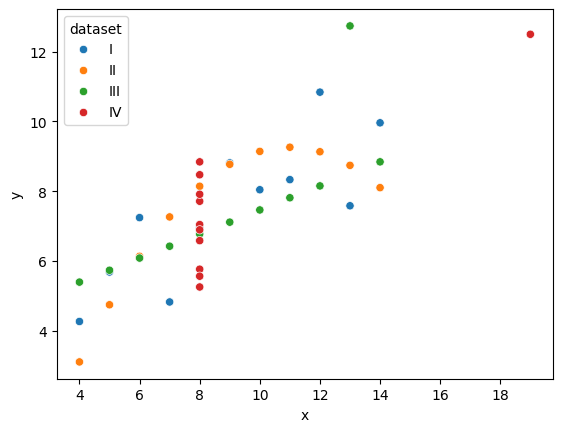

In [ ]:
sns.scatterplot(data=dfb,x='x',y='y', hue = 'dataset')

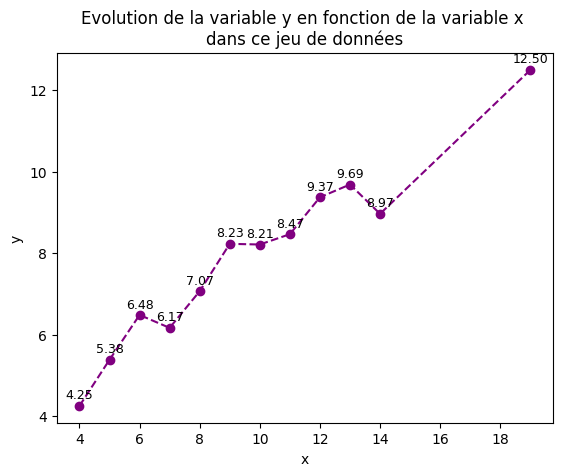

In [ ]:
means = dfb.groupby('x')['y'].mean()
means.plot(color='purple', marker='o', linestyle='--')
plt.title("Evolution de la variable y en fonction de la variable x \ndans ce jeu de données")
plt.xlabel("x")
plt.ylabel("y")
for x, y in means.items():
    plt.text(x, y + 0.1, f"{y:.2f}", ha='center', va='bottom', fontsize=9, color='black')
plt.show()

In [ ]:
dfb.groupby('dataset')[['x','y']].describe()

x                                               y            \
        count mean       std  min  25%  50%   75%   max count      mean   
dataset                                                                   
I        11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
II       11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
III      11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500000   
IV       11.0  9.0  3.316625  8.0  8.0  8.0   8.0  19.0  11.0  7.500909   

                                                   
              std   min    25%   50%   75%    max  
dataset                                            
I        2.031568  4.26  6.315  7.58  8.57  10.84  
II       2.031657  3.10  6.695  8.14  8.95   9.26  
III      2.030424  5.39  6.250  7.11  7.98  12.74  
IV       2.030579  5.25  6.170  7.04  8.19  12.50

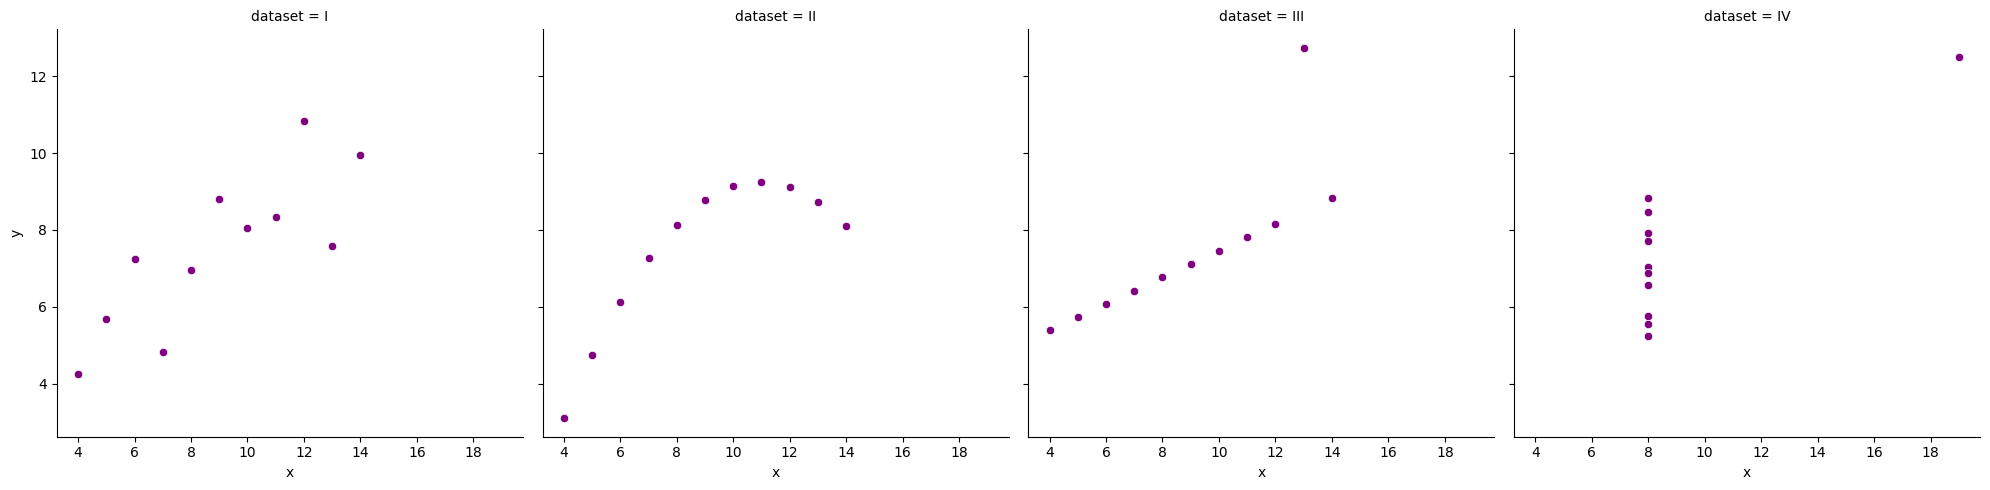

In [ ]:
sns.relplot(data=dfb, x="x", y="y", col="dataset", color='purple')